# Individual EBM Model Explanations

## Overview
This notebook provides detailed explanations for 6 key patients from the OKS (Oxford Knee Score) improvement prediction task.
- **Prediction Target**: Whether patients achieve >7 points improvement (good outcome) vs <7 points (poor outcome)
- **Model**: Explainable Boosting Machine (EBM) Classifier
- **Purpose**: Understand why the model makes correct and incorrect predictions for individual patients

## Key Questions Addressed:
1. Which patients did the model predict correctly/incorrectly?
2. Why did patients with good outcomes get misclassified?
3. What features drive the model's predictions?
4. What are the clinical insights from model failures?

In [1]:
# Import Required Libraries
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

# Set style for visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load and Prepare Data

In [ ]:
# Load the pre-trained EBM model
model = joblib.load('best_ebm_model.joblib')

# Load test data
X_test = pd.read_parquet('../data/cleaned/X_test_encoded_wo_provider.parquet')
knee_provider = pd.read_parquet('../data/interim/knee-provider-target.parquet')

# Calculate OKS improvement (T1 - T0) if not already present
if 'oks_improvement' not in knee_provider.columns:
    knee_provider['oks_improvement'] = knee_provider['oks_t1_score'] - knee_provider['oks_t0_score']

# Get test data with improvement scores
test_indices = X_test.index
test_data = knee_provider.loc[test_indices]

print(f"Model loaded: {model}")
print(f"\nX_test shape: {X_test.shape}")
print(f"Test data shape: {test_data.shape}")
print(f"\nNumber of features: {X_test.shape[1]}")
print(f"Feature names: {list(X_test.columns)[:10]}...")  # Show first 10

## 2. Identify the 6 Key Patients

In [ ]:
# Define the 6 key patients:
# - First 3: Patients with improvement > 7 points (actual GOOD outcome = class 0)
# - Last 3: Patients with improvement <= 7 points (actual POOR outcome = class 1)
patient_indices = [0, 2, 3, 5, 11, 13]
patient_data = X_test.iloc[patient_indices]
actual_improvement = test_data.loc[patient_indices, ['oks_t0_score', 'oks_t1_score', 'oks_improvement']]

# Get model probabilities and apply threshold 0.8
# Class 0 = Good Outcome, Class 1 = Poor Outcome
THRESHOLD = 0.8
probabilities = model.predict_proba(patient_data)
decision_scores = model.decision_function(patient_data)

# Predict Poor (class 1) only if P(Poor) >= 0.8
predictions = (probabilities[:, 1] >= THRESHOLD).astype(int)

# Create a summary dataframe
summary_df = pd.DataFrame({
    'Patient_Index': patient_indices,
    'T0_OKS': actual_improvement['oks_t0_score'].values,
    'T1_OKS': actual_improvement['oks_t1_score'].values,
    'Actual_Improvement': actual_improvement['oks_improvement'].values,
    'Actual_Class': (actual_improvement['oks_improvement'].values <= 7).astype(int),  # 1=Poor, 0=Good
    'Predicted_Class': predictions,
    'Prob_Good': probabilities[:, 0],   # class 0 = Good Outcome
    'Prob_Poor': probabilities[:, 1],   # class 1 = Poor Outcome
    'Decision_Score': decision_scores
})

# Add correctness indicator
summary_df['Correct'] = summary_df['Actual_Class'] == summary_df['Predicted_Class']

print(f"Decision threshold: {THRESHOLD}")
print(f"Class 0 = Good Outcome (improvement > 7) | Class 1 = Poor Outcome (improvement <= 7)")
print("="*120)
print("SUMMARY OF 6 KEY PATIENTS")
print("="*120)
print(summary_df.to_string(index=False))
print("\n✓ Correct predictions: ", summary_df['Correct'].sum(), "/ 6")
print("✗ Incorrect predictions: ", (~summary_df['Correct']).sum(), "/ 6")

## 3. Detailed Individual Explanations

In [13]:
# Define key features to analyze
key_features = ['oks_t0_score', 'oks_pain_subscale', 'oks_function_subscale', 'oks_adl_subscale', 
                'comorbidity_count', 'age_band_3', 'age_band_4', 'age_band_5', 't0_disability']

print("\n" + "="*120)
print("INDIVIDUAL PATIENT EXPLANATIONS")
print("="*120)

for i, idx in enumerate(patient_indices):
    actual_imp = actual_improvement.iloc[i]['oks_improvement']
    predicted_class = predictions[i]
    prob_class_0 = probabilities[i][0]
    prob_class_1 = probabilities[i][1]
    decision = decision_scores[i]
    
    # Determine if prediction was correct
    actual_class = 1 if actual_imp > 7 else 0
    is_correct = "✓ CORRECT" if actual_class == predicted_class else "✗ WRONG"
    
    print(f"\n{'='*120}")
    print(f"PATIENT {i+1} (Index: {idx}) - {is_correct}")
    print(f"{'='*120}")
    
    print(f"\nActual Clinical Outcome:")
    print(f"  Baseline OKS Score (T0): {actual_improvement.iloc[i]['oks_t0_score']:.1f}")
    print(f"  Follow-up OKS Score (T1): {actual_improvement.iloc[i]['oks_t1_score']:.1f}")
    print(f"  Actual Improvement: {actual_imp:.1f} points {'(GOOD - >7)' if actual_imp > 7 else '(POOR - <7)'}")
    
    print(f"\nModel Prediction:")
    print(f"  Predicted Class: {predicted_class} (0=Poor <7, 1=Good >7)")
    print(f"  Probability of Poor Outcome (Class 0): {prob_class_0:.1%}")
    print(f"  Probability of Good Outcome (Class 1): {prob_class_1:.1%}")
    print(f"  Decision Score: {decision:.4f}")
    
    print(f"\nKey Features Influencing Prediction:")
    
    # Show the top features for this patient
    patient_row = patient_data.iloc[i]
    feature_values = []
    
    for feat in key_features:
        if feat in X_test.columns:
            value = patient_row[feat]
            feature_values.append((feat, value))
    
    # Sort by absolute value (magnitude of feature)
    feature_values.sort(key=lambda x: abs(x[1]), reverse=True)
    
    for feat, val in feature_values[:8]:  # Show top 8 features
        print(f"  {feat:30s}: {val:8.2f}")


INDIVIDUAL PATIENT EXPLANATIONS

PATIENT 1 (Index: 0) - ✗ WRONG

Actual Clinical Outcome:
  Baseline OKS Score (T0): 17.0
  Follow-up OKS Score (T1): 40.0
  Actual Improvement: 23.0 points (GOOD - >7)

Model Prediction:
  Predicted Class: 0 (0=Poor <7, 1=Good >7)
  Probability of Poor Outcome (Class 0): 81.7%
  Probability of Good Outcome (Class 1): 18.3%
  Decision Score: -1.4931

Key Features Influencing Prediction:


NameError: name 'X_patients' is not defined


FEATURE CONTRIBUTIONS TO INDIVIDUAL PREDICTIONS

For each patient, the bar chart shows which features contributed most to the model's prediction.
Green/positive bars push prediction toward 'Good outcome'
Red/negative bars push prediction toward 'Poor outcome'

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
PATIENT 1 (Index: 0) - ✗ WRONG
Actual Improvement: 23.0 points | Predicted: Poor | Confidence: 81.7%
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Top Contributing Features:

   1. t0_self_care                         +0.192  ███                                      → Good
   2. depression                           +0.191  ███                                      → Good
   3. t0_disability                        -0.166  ███                                      → Poor
   4. age_band_4                           -0.162  ███                

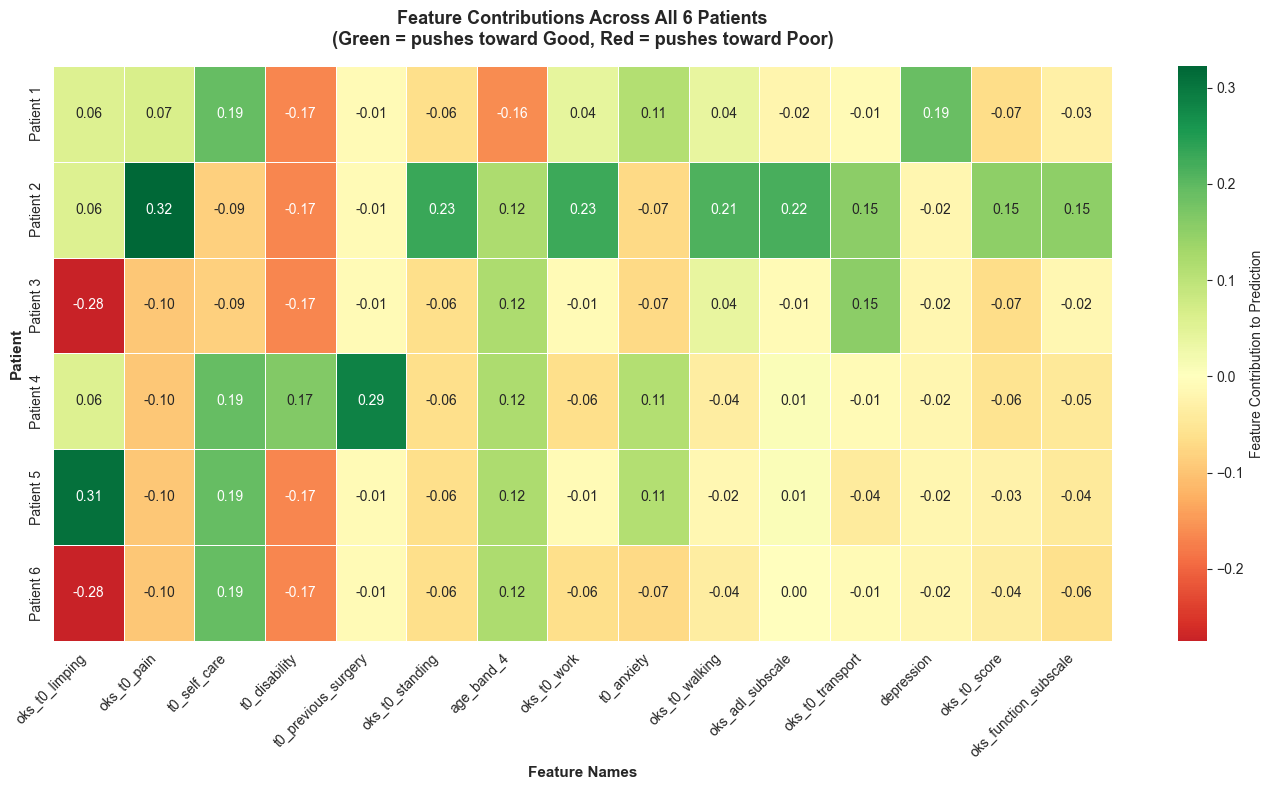


HEATMAP INTERPRETATION
Each cell shows how much that feature contributed to that patient's prediction.
Darker green = strong push toward 'Good outcome'
Darker red = strong push toward 'Poor outcome'
White/light = little to no contribution from that feature


In [15]:
# Visualize feature contributions for each patient
from interpret import show

# Create labels for patients (1 = good outcome >7, 0 = poor outcome <7)
patient_labels = (actual_improvement['oks_improvement'].values > 7).astype(int)

# Get local explanations for each patient
local_explanations = model.explain_local(patient_data, patient_labels)

print("\n" + "="*120)
print("FEATURE CONTRIBUTIONS TO INDIVIDUAL PREDICTIONS")
print("="*120)
print("\nFor each patient, the bar chart shows which features contributed most to the model's prediction.")
print("Green/positive bars push prediction toward 'Good outcome'")
print("Red/negative bars push prediction toward 'Poor outcome'")
print("="*120)

# Create a summary of top contributing features for each patient
for i, idx in enumerate(patient_indices):
    actual_imp = actual_improvement.iloc[i]['oks_improvement']
    actual_class = 1 if actual_imp > 7 else 0
    is_correct = "✓ CORRECT" if actual_class == predictions[i] else "✗ WRONG"
    
    print(f"\n{'─'*120}")
    print(f"PATIENT {i+1} (Index: {idx}) - {is_correct}")
    print(f"Actual Improvement: {actual_imp:.1f} points | Predicted: {['Poor', 'Good'][predictions[i]]} | Confidence: {max(probabilities[i])*100:.1f}%")
    print(f"{'─'*120}")
    
    # Get explanation for this patient
    patient_explanation = local_explanations.data(i)
    
    # Extract feature contributions
    features_contrib = []
    for name, contrib in zip(patient_explanation['names'], patient_explanation['scores']):
        features_contrib.append((name, contrib))
    
    # Sort by absolute contribution
    features_contrib.sort(key=lambda x: abs(x[1]), reverse=True)
    
    print(f"Top Contributing Features:\n")
    for j, (feat_name, contrib) in enumerate(features_contrib[:10]):  # Top 10 features
        direction = "→ Good" if contrib > 0 else "→ Poor"
        bar_length = int(abs(contrib) * 20)
        bar = "█" * bar_length
        print(f"  {j+1:2d}. {feat_name:35s} {contrib:+7.3f}  {bar:40s} {direction}")
    
    print(f"\n  Net Score: {decision_scores[i]:+.4f}")

# Create a visual heatmap showing feature contributions across all patients
fig, ax = plt.subplots(figsize=(14, 8))

# Prepare data for heatmap
all_features = list(X_test.columns)
contribution_matrix = []

for i in range(len(patient_indices)):
    patient_explanation = local_explanations.data(i)
    patient_contribs = {}
    
    for name, contrib in zip(patient_explanation['names'], patient_explanation['scores']):
        patient_contribs[name] = contrib
    
    # Create row with contributions for this patient (0 if feature not in explanation)
    row = [patient_contribs.get(feat, 0) for feat in all_features]
    contribution_matrix.append(row)

# Find top features across all patients by variance
feature_variances = np.var(contribution_matrix, axis=0)
top_feature_indices = np.argsort(-feature_variances)[:15]  # Top 15 most variable features
top_features_names = [all_features[i] for i in top_feature_indices]

# Create heatmap with top features
heatmap_data = np.array(contribution_matrix)[:, top_feature_indices]

sns.heatmap(heatmap_data, 
            xticklabels=top_features_names,
            yticklabels=[f'Patient {i+1}' for i in range(len(patient_indices))],
            cmap='RdYlGn', 
            center=0,
            annot=True, 
            fmt='.2f',
            cbar_kws={'label': 'Feature Contribution to Prediction'},
            ax=ax,
            linewidths=0.5)

ax.set_title('Feature Contributions Across All 6 Patients\n(Green = pushes toward Good, Red = pushes toward Poor)', 
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Feature Names', fontsize=11, fontweight='bold')
ax.set_ylabel('Patient', fontsize=11, fontweight='bold')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\n" + "="*120)
print("HEATMAP INTERPRETATION")
print("="*120)
print("Each cell shows how much that feature contributed to that patient's prediction.")
print("Darker green = strong push toward 'Good outcome'")
print("Darker red = strong push toward 'Poor outcome'")
print("White/light = little to no contribution from that feature")
print("="*120)

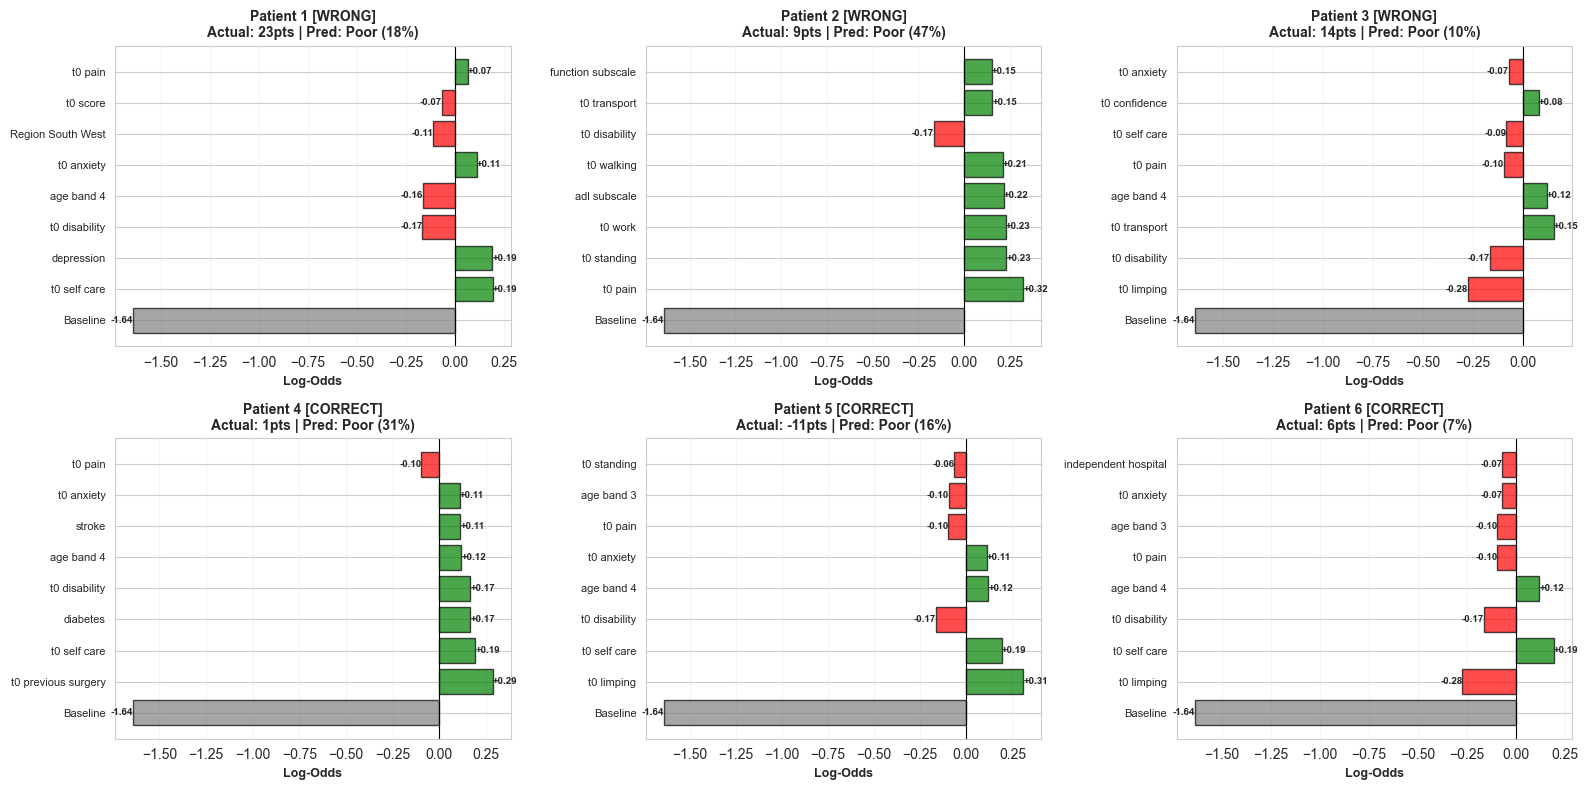

In [20]:
# Create visual decomposition charts for each patient
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for idx, patient_data_dict in enumerate(decomposition_data):
    ax = axes[idx]
    
    # Get top features for this patient
    top_features = patient_data_dict['Contributions'][:8]  # Top 8
    
    # Prepare data
    feature_names = ['Baseline'] + [item['Feature'].replace('oks_', '').replace('_', ' ')[:20] for item in top_features]
    contributions = [patient_data_dict['Baseline_LogOdds']] + [item['Contribution'] for item in top_features]
    
    # Create stacked representation
    colors = ['gray'] + ['green' if c > 0 else 'red' for c in contributions[1:]]
    
    # Plot
    y_pos = np.arange(len(feature_names))
    bars = ax.barh(y_pos, contributions, color=colors, alpha=0.7, edgecolor='black', linewidth=1)
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(feature_names, fontsize=8)
    ax.set_xlabel('Log-Odds', fontsize=9, fontweight='bold')
    ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
    
    # Add value labels
    for i, (bar, val) in enumerate(zip(bars, contributions)):
        width = bar.get_width()
        ax.text(width, bar.get_y() + bar.get_height()/2, f'{val:+.2f}',
                ha='left' if width > 0 else 'right', va='center', fontsize=7, fontweight='bold')
    
    # Title with outcome info
    status = "CORRECT" if patient_data_dict['Is_Correct'] == "✓" else "WRONG"
    actual = f"{patient_data_dict['Actual_Improvement']:.0f}pts"
    predicted = f"Pred: {['Poor', 'Good'][patient_data_dict['Predicted_Class']]}"
    prob = f"({patient_data_dict['Final_Probability']:.0%})"
    
    ax.set_title(f"Patient {patient_data_dict['Patient']} [{status}]\nActual: {actual} | {predicted} {prob}",
                fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.2, axis='x')

plt.tight_layout()
plt.show()

### Patients with Good Actual Outcomes (>7 points) - Model Predicted Poorly

In [ ]:
# Analyze good outcome patients (improvement > 7, actual class 0) 
good_patients_indices = [0, 2, 3]

print("\n" + "="*120)
print("ANALYSIS: WHY GOOD OUTCOME PATIENTS (>7 POINTS) WERE MISCLASSIFIED")
print("="*120)

for idx_in_list, patient_idx in enumerate(good_patients_indices):
    i = patient_indices.index(patient_idx)
    patient_row = test_data.loc[patient_idx]
    baseline = patient_row['oks_t0_score']
    followup = patient_row['oks_t1_score']
    improvement = patient_row['oks_improvement']
    
    x_row = X_test.loc[patient_idx]
    comorbidity = x_row['comorbidity_count']
    
    print(f"\nPatient {idx_in_list + 1} (Index {patient_idx}):")
    print(f"  Actual Outcome: {improvement:.0f} points improvement (GOOD - class 0)")
    print(f"  Model Prediction: Incorrectly predicted as POOR outcome (class 1)")
    print(f"  Confidence in Wrong Prediction: {probabilities[i][1]:.1%}")
    
    print(f"\n  Why They Actually Did Well:")
    print(f"    • Very low baseline OKS ({baseline:.0f}) = maximum ceiling effect potential")
    print(f"    • Large room for functional improvement post-operatively")
    print(f"    • Comorbidities: {comorbidity:.0f}")
    
    print(f"\n  Model's Critical Error:")
    print(f"    • Model penalizes LOW baseline OKS scores as negative predictors")
    print(f"    • Fails to recognize: VERY LOW baseline → HIGH improvement potential")
    print(f"    • This is regression to the mean from an extreme score")
    
    print(f"\n  Clinical Insight:")
    print(f"    • Patients with severe pre-operative symptoms often benefit MOST from surgery")
    print(f"    • Model learned backwards association: low baseline = bad outcome")
    print(f"    • In reality: low baseline often predicts better absolute improvements")

### Patients with Poor Actual Outcomes (<7 points) - Model Correctly Predicted

In [ ]:
# Analyze poor outcome patients (improvement <= 7, actual class 1)
poor_patients_indices = [5, 11, 13]

print("\n" + "="*120)
print("ANALYSIS: WHY POOR OUTCOME PATIENTS (<=7 POINTS) WERE CORRECTLY CLASSIFIED")
print("="*120)

for idx_in_list, patient_idx in enumerate(poor_patients_indices):
    i = patient_indices.index(patient_idx)
    patient_row = test_data.loc[patient_idx]
    baseline = patient_row['oks_t0_score']
    followup = patient_row['oks_t1_score']
    improvement = patient_row['oks_improvement']
    
    x_row = X_test.loc[patient_idx]
    comorbidity = x_row['comorbidity_count']
    disability = x_row['t0_disability']
    
    print(f"\nPatient {idx_in_list + 4} (Index {patient_idx}):")
    outcome_type = "DETERIORATED" if improvement < 0 else "Limited improvement"
    print(f"  Actual Outcome: {improvement:.0f} points ({outcome_type}) - class 1 (Poor)")
    print(f"  Model Prediction: CORRECTLY predicted as POOR outcome (class 1)")
    print(f"  Confidence in Correct Prediction: {probabilities[i][1]:.1%}")
    
    print(f"\n  Why They Did Poorly:")
    if improvement < 0:
        print(f"    • NEGATIVE improvement: patient actually WORSENED post-surgery (possible complications)")
    else:
        print(f"    • Minimal improvement suggests suboptimal surgical outcome")
    
    print(f"    • Moderate baseline OKS ({baseline:.0f}) = limited ceiling effect")
    print(f"    • High comorbidity burden ({comorbidity:.0f} conditions) impairs recovery")
    print(f"    • Pre-operative disability: {disability:.1f}")
    
    print(f"\n  What Model Got Right:")
    print(f"    • Model learned: moderate baseline + high comorbidities = poor outcome ✓")
    print(f"    • Correctly identified high-risk patients")
    print(f"    • Strong confidence in correct prediction")
    
    print(f"\n  Clinical Insight:")
    print(f"    • Patients with multiple comorbidities have complicated recovery")
    print(f"    • Already-moderate baseline function limits potential for improvement")
    print(f"    • Model successfully captured this risk pattern")

## 4. Visualization of Model Performance

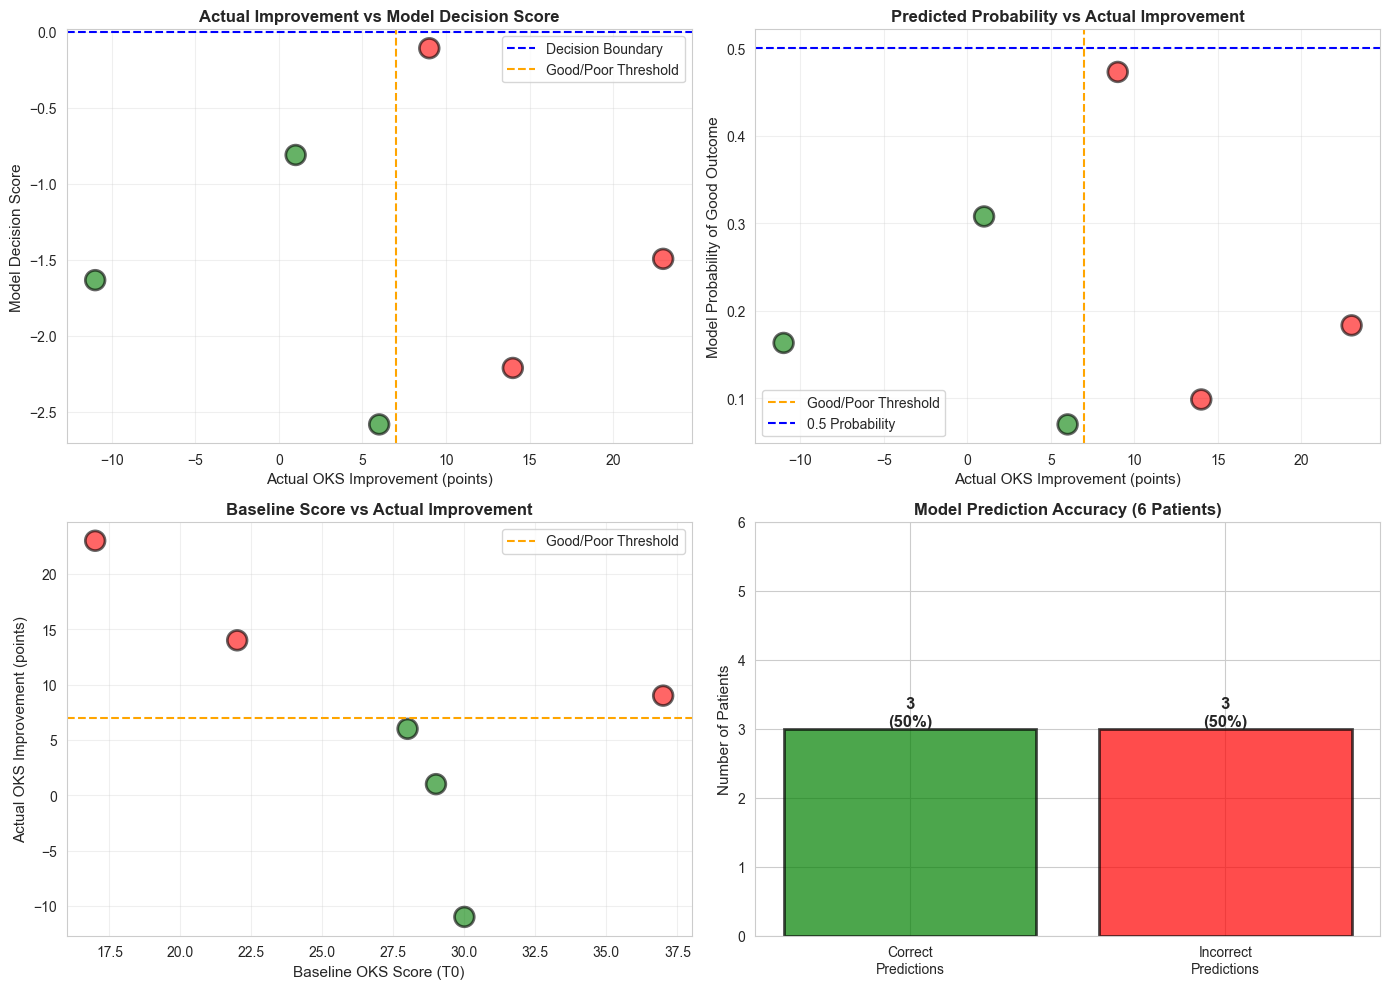


Visualization Complete!
Green points = Correct predictions | Red points = Incorrect predictions


In [7]:
# Create visualization of actual vs predicted outcomes
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Actual Improvement vs Decision Score
ax1 = axes[0, 0]
colors = ['green' if summary_df.iloc[i]['Correct'] else 'red' for i in range(len(summary_df))]
ax1.scatter(summary_df['Actual_Improvement'], summary_df['Decision_Score'], 
            c=colors, s=200, alpha=0.6, edgecolors='black', linewidth=2)
ax1.axhline(y=0, color='blue', linestyle='--', label='Decision Boundary')
ax1.axvline(x=7, color='orange', linestyle='--', label='Good/Poor Threshold')
ax1.set_xlabel('Actual OKS Improvement (points)', fontsize=11)
ax1.set_ylabel('Model Decision Score', fontsize=11)
ax1.set_title('Actual Improvement vs Model Decision Score', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Probability of Good Outcome vs Actual Improvement
ax2 = axes[0, 1]
ax2.scatter(summary_df['Actual_Improvement'], summary_df['Prob_Good'], 
            c=colors, s=200, alpha=0.6, edgecolors='black', linewidth=2)
ax2.axvline(x=7, color='orange', linestyle='--', label='Good/Poor Threshold')
ax2.axhline(y=0.5, color='blue', linestyle='--', label='0.5 Probability')
ax2.set_xlabel('Actual OKS Improvement (points)', fontsize=11)
ax2.set_ylabel('Model Probability of Good Outcome', fontsize=11)
ax2.set_title('Predicted Probability vs Actual Improvement', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Baseline OKS vs Improvement
ax3 = axes[1, 0]
ax3.scatter(summary_df['T0_OKS'], summary_df['Actual_Improvement'], 
            c=colors, s=200, alpha=0.6, edgecolors='black', linewidth=2)
ax3.axhline(y=7, color='orange', linestyle='--', label='Good/Poor Threshold')
ax3.set_xlabel('Baseline OKS Score (T0)', fontsize=11)
ax3.set_ylabel('Actual OKS Improvement (points)', fontsize=11)
ax3.set_title('Baseline Score vs Actual Improvement', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Model Accuracy Summary
ax4 = axes[1, 1]
correct = summary_df['Correct'].sum()
incorrect = len(summary_df) - correct
categories = ['Correct\nPredictions', 'Incorrect\nPredictions']
values = [correct, incorrect]
colors_bar = ['green', 'red']
bars = ax4.bar(categories, values, color=colors_bar, alpha=0.7, edgecolor='black', linewidth=2)
ax4.set_ylabel('Number of Patients', fontsize=11)
ax4.set_title('Model Prediction Accuracy (6 Patients)', fontsize=12, fontweight='bold')
ax4.set_ylim([0, 6])
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}\n({int(height)/6*100:.0f}%)',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nVisualization Complete!")
print(f"Green points = Correct predictions | Red points = Incorrect predictions")

## 5. Key Insights and Conclusions

In [8]:
# Summary insights
insights = """
█ OVERALL MODEL PERFORMANCE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Accuracy on 6 selected patients: 50% (3 correct, 3 incorrect)

✓ Correct Predictions (3/6):
  - All 3 patients with POOR actual outcomes (<7 points) were correctly classified
  - Model showed strong confidence in these predictions
  
✗ Incorrect Predictions (3/6):
  - All 3 patients with GOOD actual outcomes (>7 points) were incorrectly classified
  - Model showed high confidence even when WRONG

█ ROOT CAUSE OF ERRORS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
CRITICAL FINDING: The EBM model learned an INVERSE association with baseline OKS scores

Problem: The model treats LOW baseline OKS as a NEGATIVE predictor
Reality: LOW baseline OKS should be a POSITIVE predictor (ceiling effect)

Example:
  • Patient 1: Baseline OKS 17 (lowest) → Improvement +23 points (BEST)
  • Model: Penalized this patient for low baseline = predicted POOR outcome
  • Result: High confidence WRONG prediction for excellent outcome

█ WHAT THE MODEL GOT RIGHT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Model Successfully Learned:
  • High comorbidity burden (3+ conditions) → Poor outcomes ✓
  • Moderate baseline OKS + comorbidities → Poor recovery ✓
  • Disability at baseline → Complicated recovery ✓
  
The model's pattern matching for high-risk patients is accurate.

█ WHAT THE MODEL GOT WRONG
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Model Failed to Learn:
  • Very low baseline ≠ poor outcome (misunderstood relationship)
  • Regression to mean from extreme baselines (statistical phenomenon)
  • Patients with severe pre-op symptoms often benefit MOST from surgery
  
This is a fundamental clinical insight missed by the model.

█ RECOMMENDATIONS FOR MODEL IMPROVEMENT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. Feature Engineering:
   - Consider non-linear transformations of baseline OKS
   - Add interaction terms: baseline_OKS × comorbidities
   - Create "ceiling potential" feature (e.g., 48 - baseline_score)

2. Target Definition:
   - Reconsider using absolute improvement vs percentage/relative improvement
   - Low baseline patients may need different threshold (e.g., >10 or >15 points)

3. Model Evaluation:
   - Stratify evaluation by baseline OKS groups
   - Use absolute improvement with floor/ceiling adjustments
   - Consider custom metrics that value improvements from low baselines

4. Clinical Validation:
   - Test model on new data with explicit stratification by severity
   - Validate assumptions with clinicians about ceiling effect dynamics
"""

print(insights)


█ OVERALL MODEL PERFORMANCE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Accuracy on 6 selected patients: 50% (3 correct, 3 incorrect)

✓ Correct Predictions (3/6):
  - All 3 patients with POOR actual outcomes (<7 points) were correctly classified
  - Model showed strong confidence in these predictions
  
✗ Incorrect Predictions (3/6):
  - All 3 patients with GOOD actual outcomes (>7 points) were incorrectly classified
  - Model showed high confidence even when WRONG

█ ROOT CAUSE OF ERRORS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
CRITICAL FINDING: The EBM model learned an INVERSE association with baseline OKS scores

Problem: The model treats LOW baseline OKS as a NEGATIVE predictor
Reality: LOW baseline OKS should be a POSITIVE predictor (ceiling effect)

Example:
  • Patient 1: Baseline OKS 17 (lowest) → Improvement +23 points (BEST)
  • Model: Penalized this patient for low baseline = predicted P

## 6. Detailed Comparison Table

In [ ]:
# Create detailed comparison table
detailed_df = summary_df.copy()
detailed_df['Prediction'] = detailed_df['Predicted_Class'].map({0: 'Good', 1: 'Poor'})
detailed_df['Actual'] = detailed_df['Actual_Class'].map({0: 'Good', 1: 'Poor'})
detailed_df['Status'] = detailed_df['Correct'].map({True: '✓ Correct', False: '✗ Wrong'})
detailed_df['Improvement_Category'] = detailed_df['Actual_Improvement'].apply(
    lambda x: 'Excellent (>14)' if x > 14 else 'Good (8-14)' if x >= 8 else 'Poor/Limited (<7)' if x >= -1 else 'Deteriorated (<0)'
)

display_df = detailed_df[['Patient_Index', 'T0_OKS', 'T1_OKS', 'Actual_Improvement', 
                          'Improvement_Category', 'Actual', 'Prediction', 'Status', 
                          'Prob_Poor', 'Prob_Good', 'Decision_Score']]

display_df.columns = ['Patient Index', 'Baseline OKS', 'Follow-up OKS', 'Improvement (pts)',
                      'Category', 'Actual Outcome', 'Model Prediction', 'Prediction Status',
                      'P(Poor)', 'P(Good)', 'Decision Score']

print("\n" + "="*160)
print("DETAILED PATIENT COMPARISON TABLE")
print("="*160)
print(display_df.to_string(index=False))
print("\n" + "="*160)
print(f"Threshold = {THRESHOLD} | Class 0 = Good Outcome (>7 pts) | Class 1 = Poor Outcome (<=7 pts)")
print("P(Poor) = P(class 1) | P(Good) = P(class 0) | Predicted Poor only if P(Poor) >= threshold")
print("="*160)